# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Business Understanding — Data Task Reframing**

From a data perspective, this is a **supervised regression problem**: given a set of input features describing a used car (such as year, make, model, mileage, condition, fuel type, transmission, and location), the goal is to build a predictive model that estimates the **continuous target variable** — listing price. The key analytical objective is not only prediction accuracy, but also **feature importance and interpretability** — specifically, identifying which vehicle attributes have the strongest statistical relationship with price, so that the dealership can make informed decisions about inventory acquisition and pricing strategy.

Concretely, we aim to train a regression model (e.g., linear regression with regularization, or a comparable approach) on historical listing data, evaluate it using a held-out test set via cross-validation, and rank the input features by their coefficients or permutation importance to surface the drivers of price. Model success will be measured by minimizing prediction error (e.g., RMSE or MAE) while maintaining interpretability of the learned feature weights.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

Data Understanding — Exploratory Steps

To get familiar with the dataset and surface quality issues, we follow four sequential steps:

1. Inventory the schema — inspect column names, data types, and a sample of rows to confirm what each feature represents and whether its dtype is appropriate (e.g., "year" should be integer, not float).

2. Assess missingness — calculate the count and percentage of null values per column. Columns such as "size" (72% missing), "cylinders" (42%), and "condition" (41%) have severe missingness that will require a decision about imputation or removal during Data Preparation.

3. Profile the target variable ("price") — examine its distribution with summary statistics and a histogram. Key findings: around 32,900 listings have a price of 0 dollar (likely placeholder/free entries), around 9,200 have prices under 500 dollars, and the max value exceeds 3.7 billion dollars (clear data entry errors). The mean is heavily inflated by outliers; the median (around 13,950) is a better central estimate. These extreme values must be filtered before modeling.

4. Profile key predictive features — examine the distributions and value ranges of the most likely price drivers:
   - year: ranges from 1900 to 2022; ~8,400 entries pre-1980 are likely errors or niche collectibles that could skew the model.
   - odometer: ranges from 0 to 10,000,000; unrealistically high values suggest data entry errors.
   - condition, fuel, transmission, type: categorical features with meaningful coverage, though "condition" has 41% missing values — a critical field for price prediction.
   - manufacturer and model: 4% and 1% missing respectively; both are strong price signals and are largely available.

Key data quality issues identified:
- Price outliers (zeros, under 500, and multi-million dollar values) must be capped or filtered.
- size, cylinders, condition, and drive have missingness rates high enough to limit their direct use without imputation.
- VIN (~38% missing) is not a predictive feature and can be dropped.
- "id" and "region" are identifiers/geographic proxies — "region" may be redundant with "state".

These findings directly inform the Business Understanding: the most actionable price drivers for a dealership — year, odometer, condition, manufacturer, type, and fuel — are available in the dataset with acceptable completeness, making the regression task feasible after targeted cleaning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/vehicles.csv')

# Step 1: Schema overview
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nSample rows:')
df.head(3)

Shape: (426880, 18)

Data types:
id                int64
region           object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
state            object
dtype: object

Sample rows:


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl


In [ ]:
# Step 2: Missingness assessment
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)

Price summary statistics:
count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

Prices == $0:       32,895
Prices < $500 (>0): 9,199
Prices > $100,000:  655


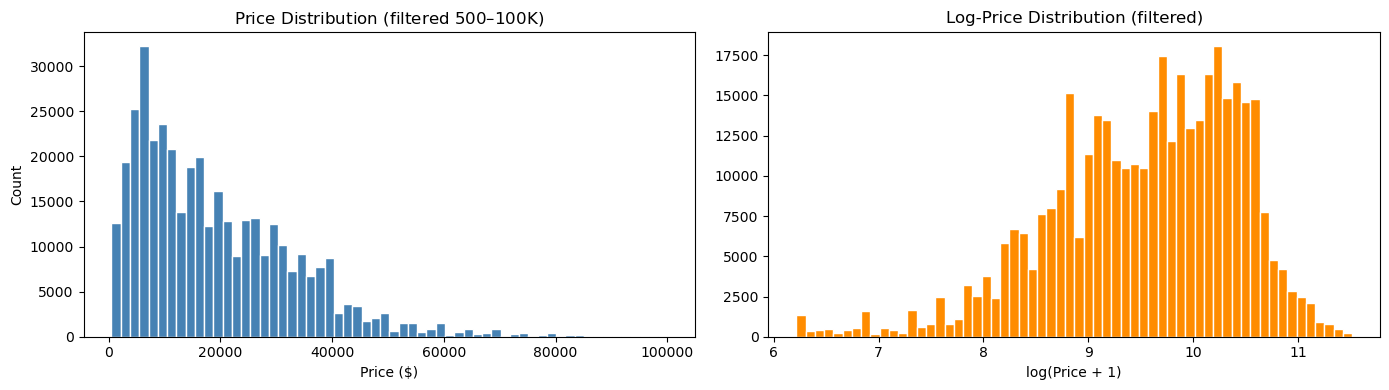


Year summary:
count    425675.000000
mean       2011.235191
std           9.452120
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64
Years before 1980: 8,413

Odometer summary:
count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
max      1.000000e+07
Name: odometer, dtype: float64

Top condition values:
condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

Top fuel types:
fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64

Top vehicle types:
type
sedan        87056
SUV          77284
pickup       43510
truck        35279
other        22110
coupe        19204
hatchback    16598
wagon        10751
Name: count, dtype: int6

In [2]:
# Step 3: Target variable (price) profile
print('Price summary statistics:')
print(df['price'].describe())
print(f"\nPrices == $0:       {(df['price'] == 0).sum():,}")
print(f"Prices < $500 (>0): {((df['price'] > 0) & (df['price'] < 500)).sum():,}")
print(f"Prices > $100,000:  {(df['price'] > 100_000).sum():,}")

# Plot price distribution after basic filter
price_filtered = df[(df['price'] >= 500) & (df['price'] <= 100_000)]['price']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(price_filtered, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (filtered $500–$100K)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[1].hist(np.log1p(price_filtered), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Log-Price Distribution (filtered)')
axes[1].set_xlabel('log(Price + 1)')
plt.tight_layout()
plt.show()

# Step 4: Key feature profiles
print('\nYear summary:')
print(df['year'].describe())
print(f"Years before 1980: {(df['year'] < 1980).sum():,}")
print('\nOdometer summary:')
print(df['odometer'].describe())
print('\nTop condition values:')
print(df['condition'].value_counts())
print('\nTop fuel types:')
print(df['fuel'].value_counts())
print('\nTop vehicle types:')
print(df['type'].value_counts().head(8))

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.